In [549]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [550]:
df_original = pd.read_excel('./datasets/dataset.xlsx')
df_original.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

In [551]:
df = df_original.copy()
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Formatage des colonnes**

In [552]:
def format_col_name(col_name_ : str) -> str:
    """
    Formats a column name by converting it to lowercase, replacing spaces with underscores,
    and trimming unnecessary whitespace. If the input contains a parenthesis, the function
    only processes the substring before the parenthesis.

    :param col_name_: The name of the column to be formatted.
    :return: The formatted column name with spaces replaced by underscores and converted
        to lowercase.
    """
    if col_name_.find('(') == -1:
        return col_name_.strip(' ').replace(' ', '_').lower()
    return col_name_[ :col_name_.find('(')].strip(' ').replace(' ', '_').lower()

In [553]:
df.rename(columns={col : format_col_name(col) for col in df.columns}, inplace=True)

In [554]:
# Création des groupes de variables
missing_columns_a = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 76
missing_columns_b = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 89

respiratory_pathogens = list(df.columns[missing_columns_a])
blood_cells = list(df.columns[missing_columns_b])
others = ['patient_age_quantile', 'sars-cov-2_exam_result']

df = df[respiratory_pathogens + blood_cells + others]

In [555]:
def encodage(df_):
    encoder_dict = {
        'detected' : 1,
        'not_detected' : 0,
        'positive' : 1,
        'negative' : 0
    }
    for col in df_.select_dtypes(include='str').columns:
        df_[col] = df_[col].map(encoder_dict)

    return df_

In [556]:
def imputation(df_):
    df_ = df_.dropna(axis=0)
    return df_

In [557]:
def selection(df_):
    # df_ = df_[blood_cells + others]
    return df_

In [558]:
def normalisation(df_):
    return df_

In [559]:
def preprocessing(df_):
    df_ = selection(df_)
    df_ = encodage(df_)
    df_ = imputation(df_)
    df_ = normalisation(df_)

    X_ = df_.drop(columns='sars-cov-2_exam_result')
    y_ = df_['sars-cov-2_exam_result']

    print(f"X shape ==> {X_.shape}")
    print(f"y shape ==> {y_.shape}")
    return X_, y_

In [560]:
from sklearn.model_selection import train_test_split, learning_curve

trainset, testset = train_test_split(df, test_size=0.2, random_state=321)

In [561]:
X_train, y_train = preprocessing(trainset)

X shape ==> (296, 32)
y shape ==> (296,)


In [562]:
X_test, y_test = preprocessing(testset)

X shape ==> (66, 32)
y shape ==> (66,)


In [563]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [564]:
model = DecisionTreeClassifier(random_state=321)

In [565]:
def evaluation():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(confusion_matrix(y_pred=y_pred, y_true=y_test))
    print(accuracy_score(y_pred=y_pred, y_true=y_test))
    print(f1_score(y_pred=y_pred, y_true=y_test))
    print(classification_report(y_pred=y_pred, y_true=y_test))

In [566]:
evaluation()

[[46  7]
 [ 6  7]]
0.803030303030303
0.5185185185185185
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        53
           1       0.50      0.54      0.52        13

    accuracy                           0.80        66
   macro avg       0.69      0.70      0.70        66
weighted avg       0.81      0.80      0.81        66



In [567]:
N, train_score, val_score = learning_curve(estimator=model, X=X_train, y=y_train, cv=5, train_sizes=np.linspace(0.2, 1.0, 10), random_state=321, scoring='f1')

/var/data/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/var/data/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/var/data/python/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/data/python/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/var/data/python/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _ca

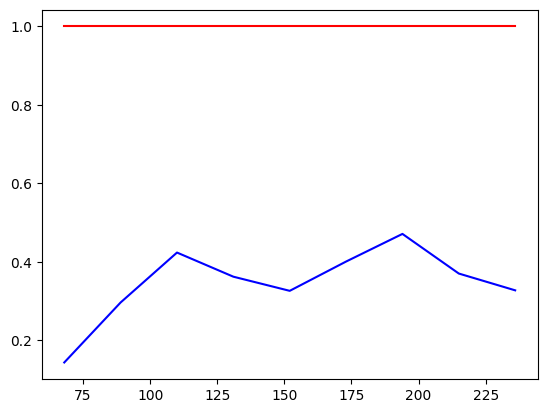

In [568]:
plt.figure()
plt.plot(N, train_score.mean(axis=1), color="red")
plt.plot(N, val_score.mean(axis=1), color="blue")
plt.show()

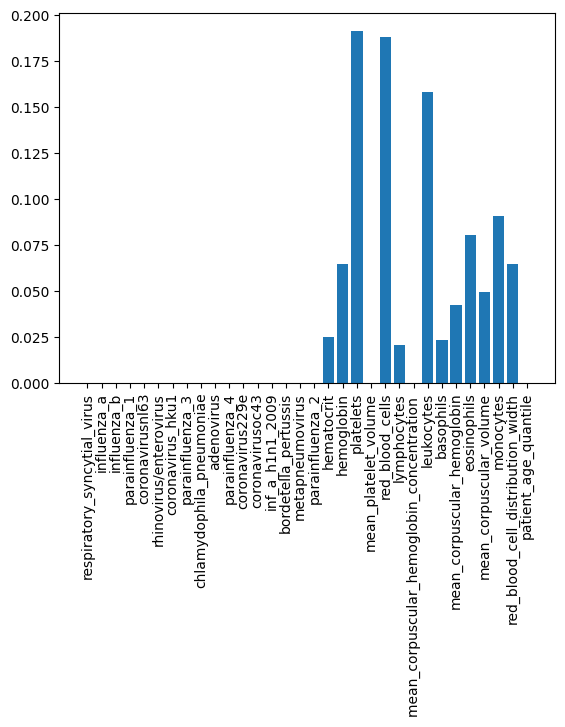

In [569]:
plt.figure()
plt.xticks(rotation=90)
plt.bar(height=model.feature_importances_, x=X_test.columns)